<h1>Closed-loop learning as an inference method</h1>

<h3>Gabriele Cerioli, BSc Physics UNITS, Intership Abdus Salam's International Centre for Theoretical Physics</h3>

In [670]:
import numpy as np

# create a random number generator
rng = np.random.default_rng()

# Parameters
mean_0 = 10        # center of the distribution
std_dev = 10     # standard deviation (spread)
n_samples = 1000  # number of values to generate


# Generate samples
samples = rng.normal(loc=float(mean_0), scale=float(std_dev), size=int(n_samples))

#print(samples)

In [671]:
def mean_estimator(samples):
    mean=np.average(samples)
    return mean

mean=mean_estimator(samples)
print(mean_estimator(samples))

def variance_estimator(samples):
    variance=np.var(samples)
    return variance
variance=variance_estimator(samples)
print(np.sqrt(variance_estimator(samples)))

9.820514176229244
10.319724177504485


In [672]:
def samples_updator(samples, M):
    synthetic=rng.normal(loc=float(mean_estimator(samples)), scale=float(np.sqrt(variance_estimator(samples))), size=int(n_samples))
    new_sample=np.concatenate((samples,synthetic))
    return new_sample

samples=samples_updator(samples,1)

print(mean_estimator(samples))

9.967774370764499


In [673]:
it=100
for i in range(0,it):
    samples=samples_updator(samples,10)
    mean_updated=mean_estimator(samples)
    variance_updated=variance_estimator(samples)

In [674]:
print("Original mean:", mean)
print("Mean after CLL: ", mean_updated)
print("Original STD_DEV: ", np.sqrt(variance))
print("STD_DEV after CLL: ", np.sqrt(variance_updated))

Original mean: 9.820514176229244
Mean after CLL:  10.154249413457858
Original STD_DEV:  10.319724177504485
STD_DEV after CLL:  10.498220084679206


<h2>Let's define a metric to see if CLL helped us estimate the parameters</h2>

In [675]:
quality_mean=(np.abs(np.sqrt(mean)-mean_0)-np.abs(np.sqrt(mean_updated)-mean_0))*100/mean
print("Quality of CLL on mean estimation:",quality_mean)

quality_stdev=(np.abs(np.sqrt(variance)-std_dev)-np.abs(np.sqrt(variance_updated)-std_dev))*100/np.sqrt(variance)
print("Quality of CLL on standard deviation estimation:", quality_stdev)


Quality of CLL on mean estimation: 0.5376840714269784
Quality of CLL on standard deviation estimation: -1.7296577321690088


In [676]:
import random
trials=10000
mean_quality_total=0
stdev_quality_total=0
it=10
n_samples=300
mean_total_quality=[]
stddev_total_quality=[]
for j in range (trials):
    mean_0 = random.randint(1,10)        # center of the distribution
    std_dev =random.randint(1,10)     # standard deviation (spread)
    # Generate samples
    samples = rng.normal(loc=float(mean_0), scale=float(std_dev), size=n_samples)
    mean=mean_estimator(samples)
    variance=variance_estimator(samples)
    for i in range(0,it):
        samples=samples_updator(samples,10)
    mean_updated=mean_estimator(samples)
    variance_updated=variance_estimator(samples)
    quality_mean=(np.abs(mean-mean_0)-np.abs(mean_updated-mean_0))/mean_0
    quality_stdev=(np.abs(np.sqrt(variance)-std_dev)-np.abs(np.sqrt(variance_updated)-std_dev))/std_dev
    mean_quality_total+=quality_mean
    stdev_quality_total+=quality_stdev
    mean_total_quality.append(quality_mean)
    stddev_total_quality.append(quality_stdev)

print("Average mean quality:", mean_quality_total/trials)
print("Average stdev quality: ", stdev_quality_total/trials)

Average mean quality: -0.019089408424692617
Average stdev quality:  -0.008042770283611375


<h3>Let's do an histogram of the mean and stddev</h3>

[np.float64(0.0018758606461427203), np.float64(-0.009326605316064551), np.float64(0.0007597046002246385), np.float64(0.006640903571224488), np.float64(0.005293444151004856), np.float64(-0.006702623614491492), np.float64(-0.00427628270534693), np.float64(-0.01987828455604885), np.float64(0.015536053357361683), np.float64(0.008254676090548961), np.float64(0.006782635207373988), np.float64(0.03874185013809992), np.float64(-0.03824796354565484), np.float64(-0.014651538991894928), np.float64(-0.007952566019011264), np.float64(0.008112670334190497), np.float64(0.010166444673697908), np.float64(-0.02034013148914187), np.float64(-0.04337200065219883), np.float64(0.003211841665529569), np.float64(-0.012912796681068706), np.float64(0.004339224029082378), np.float64(-0.01001171450125923), np.float64(-0.008289567128722197), np.float64(-0.005203678697975889), np.float64(0.0070492499118362415), np.float64(-0.023369512735697207), np.float64(0.024557113947252417), np.float64(-0.009552033272652543), np

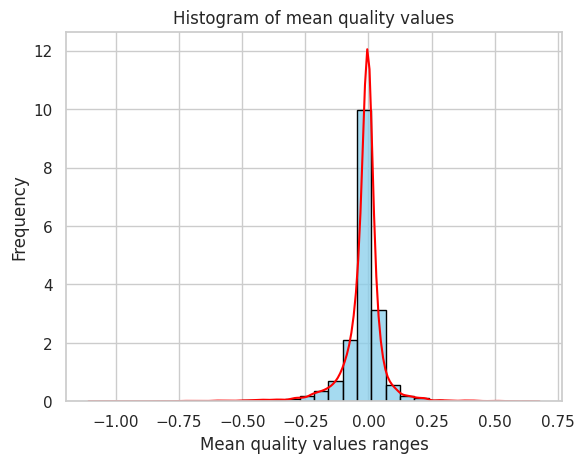

In [677]:
print(stddev_total_quality)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.histplot(mean_total_quality, bins=30, kde=False, color="skyblue",edgecolor="black", stat="density")
sns.kdeplot(mean_total_quality, color="red")
plt.title("Histogram of mean quality values")
plt.xlabel("Mean quality values ranges")
plt.ylabel("Frequency")

plt.show()

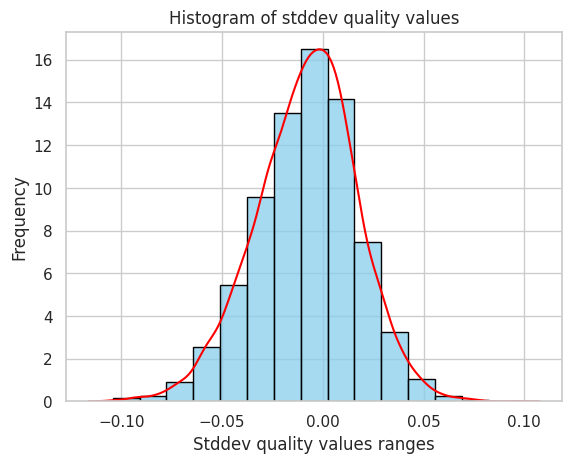

In [678]:
sns.set(style="whitegrid")
sns.histplot(stddev_total_quality, bins=15, kde=False, color="skyblue",edgecolor="black", stat="density")
sns.kdeplot(stddev_total_quality, color="red")
plt.title("Histogram of stddev quality values")
plt.xlabel("Stddev quality values ranges")
plt.ylabel("Frequency")

plt.show()